In [53]:
import sys
# add path to gp-quadrature
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature')
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature/kernels')
from kernels import SquaredExponential
from vanilla_gp_sampling import sample_bernoulli_gp
from efgpnd import ToeplitzND, compute_convolution_vector_vectorized_dD
import time
import torch
from efgpnd import NUFFT
from cg import ConjugateGradients
from torch import vmap
# from PG_GP import *
from typing import Callable
from matplotlib import pyplot as plt

In [54]:
#default to float64
torch.set_default_dtype(torch.float64)

# --- Parameters ---
n = 700  # Number of points
d = 2 # Dimensionality of the input space
true_length_scale =0.1
true_variance = 1
dtype = torch.float64  # Use float64 as in the original example
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
print(f"Using device: {device}")

# --- Generate Input Points ---
# Generate random points in d-dimensional space from -1 to 1
x = torch.rand(n, d, dtype=dtype, device=device) * 2 - 1
y,f = sample_bernoulli_gp(x,length_scale=true_length_scale,variance=true_variance)
rdtype = torch.float64
cdtype = torch.complex128
jitter = 1e-5


Using device: cpu


In [55]:
# define device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [56]:
import torch
import torch.nn as nn
from typing import List, Iterator, Tuple, Optional, Union
from torch.optim import Adam
from utils.kernels import get_xis
import math



# Setup

In [57]:
class qVariationalParams(nn.Module):
    """Variational parameters for the Polyagamma GP."""
    def __init__(self, n, device=None, dtype=torch.float64):
        """
        Initialize variational parameters.
        
        Args:
            n: Number of data points
            device: torch device
            dtype: torch dtype
        """
        super().__init__()
        self.Delta = nn.Parameter(torch.full((n,), 0.25, dtype=dtype, device=device))
q = qVariationalParams(n)


# All the epsilons here

In [58]:
nufft_eps = 1e-7
cg_tol = 1e-6
eps = 1e-4
trunc_eps = 1e-2

In [59]:
rdtype = x.dtype
cdtype = torch.complex128

In [60]:
# kernel = SquaredExponential(dimension = d,init_lengthscale=.1,init_variance=.4)
kernel = SquaredExponential(dimension = d,init_lengthscale=0.2,init_variance=1.25)

x       = x.to(device, rdtype)
data = x 
y       = y.to(device, rdtype)
if x.ndim == 1:
    x = x.unsqueeze(-1)


In [61]:
def setup_spectral_representation(x, kernel, eps, trunc_eps, device, rdtype, cdtype):
    x0 = x.min(dim=0).values  
    x1 = x.max(dim=0).values  

    if x.ndim == 1:
        x = x.unsqueeze(-1)
    d = x.shape[1]
    domain_lengths = x1 - x0
    L = domain_lengths.max()
    N = x.shape[0]
    xis_1d, h, mtot = get_xis(kernel_obj=kernel, eps=eps, L=L, use_integral=True, l2scaled=False,trunc_eps=trunc_eps)
    grids = torch.meshgrid(*(xis_1d for _ in range(d)), indexing='ij') # makes tensor product Jm 
    xis = torch.stack(grids, dim=-1).view(-1, d) 
    spec_density = kernel.spectral_density(xis).to(dtype=rdtype)
    # spec_density = torch.clamp(spec_density, min=1e-4)
    ws2 = spec_density * h**d
    ws2 = ws2.to(device=device, dtype=cdtype)
    ws = torch.sqrt(ws2) # (mtot**d,1)

    m_conv = (mtot - 1) // 2
    v_kernel = compute_convolution_vector_vectorized_dD(m_conv, x, h).to(dtype=cdtype)
    toeplitz = ToeplitzND(v_kernel, force_pow2=True)   
    spec_grad = kernel.spectral_grad(xis)
    Dprime  = (h**d * spec_grad).to(cdtype)  # (M, 3)
    
    
    return xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad

xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad = setup_spectral_representation(x, kernel, eps,trunc_eps, device, rdtype, cdtype)
ws2 = ws.pow(2)
delta = (q.Delta.to(dtype=cdtype, device=device)).clone()



In [62]:
def naive_kernel(x,xis):
    F_train = torch.exp(2 * math.pi * 1j * torch.matmul(x, xis.T)).to(cdtype)
    return F_train
F_train = naive_kernel(x,xis)
W_F_train_star = ws.unsqueeze(1) * F_train.conj().T
K_train = (F_train * ws) @ W_F_train_star

In [63]:
# Create the NUFFT operator
OUT = (mtot,)*d
nufft_op = NUFFT(x, torch.zeros_like(x), h, nufft_eps, cdtype=cdtype, device=device)

# Define the simplified helper functions
fadj = lambda v: nufft_op.type1(v, out_shape=OUT).reshape(-1)    # F* apply: nonuniform → uniform
fwd = lambda fk: nufft_op.type2(fk, out_shape=OUT)         
fadj_batched = vmap(fadj, in_dims=0, out_dims=0)
fwd_batched = vmap(fwd, in_dims=0, out_dims=0)
fadj_b = fadj_batched       # F apply:  uniform → nonuniform

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/torch/_tensor.py:1218: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)


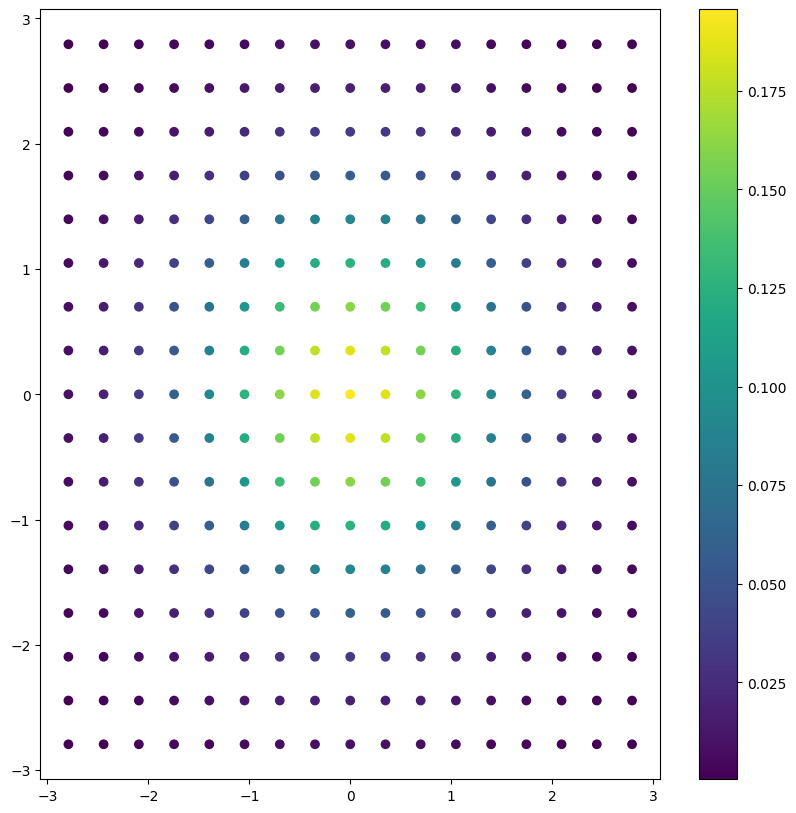

In [64]:
# plot ws in 2d wrt xis 
if d==2:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,10))
    plt.scatter(xis[:,0], xis[:,1], c=ws, cmap='viridis')
    plt.colorbar()
    plt.show()


In [65]:
def setup_sigma_solver(toeplitz, fadj_batched, fwd_batched, ws, ws2, xis= xis):
    """
    Setup operator for Sigma_z solver that captures the needed NUFFT operations
    and weights. Returns configured functions for preconditioning and solving.
    """
    
    def precond_setup(x: torch.Tensor, delta_buf: torch.Tensor,cg_tol:float=1e-10) -> torch.Tensor:
        # solve (I + δ̄·Ψ^*Ψ) y = x by CG in M-dim Toeplitz space
        # this is cheap: no NUFFT, just toeplitz(ws * x)
        def L0(u):
            return u + delta_buf.mean()*(ws * toeplitz(ws * u))
        y = ConjugateGradients(L0, x, torch.zeros_like(x), tol=cg_tol,early_stopping=True).solve()
        return y
    
    def Sigma_z_mm(
        z: torch.Tensor,
        delta_buf: torch.Tensor,
        fadj_batched: fadj_batched,
        fwd_batched: fwd_batched, 
        ws: torch.Tensor,
        ws2: torch.Tensor,
        cg_tol: float = 1e-10,
        vanilla: bool = True,
    ) -> torch.Tensor:
        """
        Exact warm‐start for Σ_z z = (K^{-1} + Δ)^{-1} z
        via one M×M CG solve in feature‐space.
        """
        vector_input = (z.dim() == 1)
        ws2 = ws**2
        if vector_input:
            z = z.unsqueeze(0)
        if vanilla:
            jitter =  1e-6
            F_train = naive_kernel(x, xis)
            Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
            Kff = Kff.real                     # (n,n)

            # 2) PG variational parameter

            omega = q.Delta

            # build K = Kff + jitter·I
            K = Kff + jitter * torch.eye(n, device=device)
            try:
                L = torch.linalg.cholesky(K, upper=False)
            except RuntimeError:
                # fallback: add more jitter if not positive definite
                K = Kff + (jitter * 10) * torch.eye(n, device=device)
                L = torch.linalg.cholesky(K, upper=False)

            # K⁻¹ via Cholesky (never invert directly)
            I = torch.eye(n, device=device,dtype=rdtype)
            K_inv = torch.cholesky_solve(I, L, upper=False)  # (n,n)

            # S⁻¹ = K⁻¹ + diag(ω)  ⇒  S = (S⁻¹)⁻¹
            S_inv = K_inv + torch.diag(omega)
            try:
                LS = torch.linalg.cholesky(S_inv, upper=False)
            except RuntimeError:
                # fallback: add more jitter if not positive definite
                print('Adding more jitter to Sigma z mm ')
                S_inv = S_inv + (jitter * 10) * torch.eye(n, device=device)
                LS = torch.linalg.cholesky(S_inv, upper=False)
            S = torch.cholesky_inverse(LS, upper=False)  # (n,n)
                # Solve L_A @ y = zT
            y = S.to(dtype=cdtype)@z.to(dtype=cdtype).T
            return y.T
        else:
            jitter_val = 1e-6
            # 1) make (batch,n)


            # 2) gather Δ = diag(delta_buf)
            Δ = delta_buf.view(1, -1).to(z)      # shape (1,n) for broadcasting

            # 3) compute g = K z = Ψ Ψ^* z
            z_feat = fadj_batched(z)             # (batch, M)
            g      = fwd_batched(ws2 * z_feat)   # (batch, n)

            # 4) RHS r = Ψ^*(Δ g)
            # print(Δ.shape,g.shape)

            weighted_g = Δ * g                   # (batch, n)
            r          = ws * fadj_batched(weighted_g)  # (batch, M)

            # 5) define L(u) = (I + Ψ^* Δ Ψ) u
            def L(u: torch.Tensor) -> torch.Tensor:
                psi_u    = fwd_batched(ws * u)        # (batch, n)
                weighted = Δ * psi_u                  # (batch, n)
                return u + ws * fadj_batched(weighted) +jitter_val * u  # (batch, M)

            # 6) solve L(w) = r
            # conj = ConjugateGradients(L, r,
            #      torch.zeros_like(r),tol=1e-7,early_stopping=True,)
            precond = lambda x: precond_setup(x, delta_buf,cg_tol)
            conj = ConjugateGradients(L, r,
                torch.zeros_like(r),tol=cg_tol,early_stopping=True,M_inv_apply=precond)
            w = conj.solve()         # (batch, M)
            print(f'Sigma z mm conj.iters_completed: {conj.iters_completed}')

            # 7) reconstruct v = g - Ψ w
            v = g - fwd_batched(ws * w)             # (batch, n)

            # 8) drop back to 1D if needed
            if vector_input:
                v = v.squeeze(0)

            return v
    
    return precond_setup, Sigma_z_mm

# Setup the sigma solver with current NUFFT operations
# precond_setup, Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched, ws, ws2)


def estep(
    y, q,
    max_iters=5, rho0=1.0, gamma=1e-3,
    tol=1e-4, verbose=True, J=5, cg_tol=cg_tol, toeplitz=toeplitz, fadj_batched=fadj_batched, fwd_batched=fwd_batched, ws=ws, ws2=ws2, xis=xis,
    vanilla: bool = False,
):
    """
    Polyagamma GP E-step (batched, no_grad).
    Updates q.Delta in-place.
    Returns final m, Sigma_diags, and predictive acc.
    """
    n = y.numel()
    # Setup the sigma solver with current NUFFT operations
    precond_setup, Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched, ws, ws2,xis=xis)
    # Pre-allocate buffers
    y_center = (y.to(dtype=cdtype, device=device) - 0.5)  # (n,)
    probes   = torch.empty((J, n), device=device, dtype=rdtype)
    rhos     = rho0 / (1 + gamma * torch.arange(max_iters, device=device, dtype=rdtype))

    # A mutable copy of q.Delta used in all mat-vecs
    delta_buf = q.Delta.to(dtype=cdtype, device=device).clone()  # (n,)

    with torch.no_grad():
        for it in range(max_iters):
            iter_start = time.time()
            
            # 1) update the buffer once
            delta_buf.copy_(q.Delta.to(dtype=cdtype, device=device))

            # 2) posterior mean
            t0 = time.time()
            m = Sigma_z_mm(z=y_center,delta_buf=q.Delta,cg_tol=cg_tol,fadj_batched=fadj_batched,fwd_batched=fwd_batched,ws=ws,ws2=ws2,vanilla=vanilla).real       # (n,)
            t1 = time.time()
            if verbose:
                print(f"Posterior mean time: {t1-t0:.3f}s")

            # 3) Hutchinson trace for diag(Σ)
            probes.bernoulli_(0.5).mul_(2).sub_(1)  # Rademacher: random ±1
            t0 = time.time()
            Sz = Sigma_z_mm(z=probes,delta_buf=q.Delta,cg_tol=cg_tol,fadj_batched=fadj_batched,fwd_batched=fwd_batched,ws=ws,ws2=ws2,vanilla=vanilla)             # (J,n)
            t1 = time.time()
            if verbose:
                print(f"Hutchinson trace time: {t1-t0:.3f}s")
            Sigma_diags = (probes * Sz).mean(dim=0).real  # (n,)

            # 4) Lambda and Δ update
            c2     = (Sigma_diags + m.pow(2)).clamp(min=1e-12)
            c      = c2.sqrt()
            Lambda = torch.tanh(0.5 * c) / (2 * c) # (n,)

            rho = rhos[it].item()
            q.Delta.mul_(1 - rho).add_(rho * Lambda.flatten())
            q.Delta.clamp_(min=0.0)

            iter_time = time.time() - iter_start
            resid = (q.Delta - Lambda).abs().max().item()
            if verbose:
                print(f"it {it:3d}  ρ={rho:.3f}  max|Δ−Λ|={resid:.3e}  time={iter_time:.3f}s")
                print(f"q.Delta[0]: {q.Delta[0]}")


        if verbose:
                # Compute final values using last iteration results
            denom = torch.sqrt(1.0 + (math.pi / 8.0) * Sigma_diags)
            p_hat = torch.sigmoid(m / denom)
            acc   = (p_hat.real.gt(0.5) == y).float().mean().item()
            print("predictive accuracy (analytic) =", acc)


    return m, Sigma_diags, Sz, probes, q 


In [66]:
_, Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched,ws,ws2,xis=xis)

for i in range(1):
    z_test = torch.randn(F_train.shape[0],device=device,dtype=cdtype)
    sigma_z_test = Sigma_z_mm(z_test,q.Delta,fadj_batched,fwd_batched,ws,ws2,vanilla=False)
    sigma_z_test_vanilla = Sigma_z_mm(z_test,q.Delta,fadj_batched,fwd_batched,ws,ws2,vanilla=True)
    print(f"Test {i}: {torch.allclose(sigma_z_test,sigma_z_test_vanilla,atol=1e-4)}")
    


Sigma z mm conj.iters_completed: 3
Test 0: True


In [67]:
m, Sigma_diags, Sz, probes, q = estep(
    y, q,
    max_iters   = 1,
    rho0        = 0.7,
    gamma       = 1e-3,
    tol         = 1e-6,
    verbose     = True,
    J           = 10,
    cg_tol      = cg_tol,
    toeplitz=toeplitz,
    fadj_batched=fadj_batched,
    fwd_batched=fwd_batched,
    ws=ws,
    ws2=ws2,
    vanilla=False,
)


Sigma z mm conj.iters_completed: 2
Posterior mean time: 0.124s
Sigma z mm conj.iters_completed: 2
Hutchinson trace time: 0.320s
it   0  ρ=0.700  max|Δ−Λ|=1.388e-02  time=0.444s
q.Delta[0]: 0.24399184328269452
predictive accuracy (analytic) = 0.6885714530944824


In [68]:
def m_step(
    q,
    m,                       # posterior mean ∈ ℂⁿ or ℝⁿ
    fadj_batched,
    fwd_batched,
    toeplitz,                # ToeplitzND: ℂᴹ→ℂᴹ
    ws,                     # spectral-domain weights ∈ ℝᴹ
    Dprime,                  # spectral grads ∈ ℝᴹˣᴾ
    J: int = 20,
    cg_tol: float = 1e-10,
    verbose: bool = False,
    h=h,
    d=d,
    xis=xis,
    vanilla: bool = False,
):
    cg_tol = 1e-10
    hsize = h
    device = m.device
    dtype  = m.dtype
    n      = m.numel()
    M, P   = Dprime.shape
    ws2 = ws**2

    ws2 = ws2.to(device=device, dtype=dtype)
    Dprime = Dprime.to(device=device, dtype=dtype)

    # Term I
    t0 = time.time()
    beta,_ = FstarKinv(m,toeplitz,ws,cg_tol,vanilla)
    term1 = ((beta.conj() * beta).real @ Dprime).flatten()      # shape (P,)
    t1 = time.time()
    term1_time = t1 - t0




    _, Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched,ws,ws2,xis=xis)

    # Generate probes

    probes = torch.empty((J, n), device=device, dtype=rdtype)

    probes.bernoulli_(0.5).mul_(2).sub_(1)         # ±1

    # Term II
    t0 = time.time()
    alpha,rhs_alpha = FstarKinv(probes,toeplitz,ws,cg_tol,vanilla)
    F_train = naive_kernel(data,xis)

    alpha_van,rhs_alpha_van = FstarKinv(probes,toeplitz,ws,cg_tol,vanilla=True)

    t1 = time.time()
    fstarkinv_time = t1 - t0
    
    t0 = time.time()
    Sz = Sigma_z_mm(z=probes,delta_buf=q.Delta,cg_tol=cg_tol,fadj_batched=fadj_batched,fwd_batched=fwd_batched,ws=ws,ws2=ws2,vanilla=vanilla)
    t1 = time.time()
    sigma_z_time = t1 - t0
    
    t0 = time.time()
    w,_ = FstarKinv(Sz,toeplitz,ws,cg_tol,vanilla)
    wvan,_ = FstarKinv(Sz,toeplitz,ws,cg_tol,vanilla=True)
    x = (w.conj() * alpha)


    term2 = torch.zeros(Dprime.shape[1],device=device,dtype=cdtype)


    for dim in range(Dprime.shape[1]):
        term2[dim] = ((alpha.conj()@ torch.diag(Dprime[:,dim]).to(dtype=cdtype)) * w).real.sum(axis=1).mean()




    t1 = time.time()
    term2_time = t1 - t0

    # Term III
    t0 = time.time()
    p = (rhs_alpha * alpha.conj()).sum(dim=0)
    # do i need to divide by sqrt(h**d)?
    term3 = (p.real @ Dprime) / J
    t1 = time.time()
    term3_time = t1 - t0



    if verbose:
        print(f"Term I computation time: {term1_time:.3f}s")
        print(f"Term II computation time: {term2_time:.3f}s")
        print(f"  - FstarKinv time: {fstarkinv_time:.3f}s")
        print(f"  - Sigma_z time: {sigma_z_time:.3f}s") 
        print(f"Term III computation time: {term3_time:.3f}s")
        print(f"Total computation time: {term1_time + term2_time + term3_time:.3f}s")
    print(f'term3, term3_vanilla: {term3[0]}, {term3_vanilla[0]}')
    # return term1, term2, term3_vanilla
    return term1, term2, term3


In [69]:
bigger_count = 0
smaller_count = 0
if n<2000:
    F_train = naive_kernel(x, xis)

# Numerically stable version using Cholesky solves and log-determinants
# if x.shape[0]<3000:
def compute_vanilla_gradient(x, y, m, kernel, ws, ws2, F_train, q, jitter=1e-6,Dprime=Dprime):
    """
    Compute vanilla gradient for GP classification using exact kernel matrix.
    
    Args:
        x: input points (n, d)
        y: binary labels (n,)
        m: posterior mean (n,)
        kernel: kernel object with variance and lengthscale
        ws: weights (M,)
        ws2: squared weights (M,)
        F_train: feature matrix (n, M)
        q: variational parameters object
        jitter: numerical stability parameter
        
    Returns:
        tuple: (grad_var, grad_ls, elbo)
    """
    m = m.flatten()
    W_F_train_star = torch.diag(ws) @ F_train.conj().T
    K_train = (F_train * ws) @ W_F_train_star
    # print(K_train[0,0])
    
    num_iters = 20

    """
    Returns: (ELBO, grad_var, grad_ls)
    for GP classification ELBO under Poly-Gamma augmentation,
    with manual gradients for kernel.variance and kernel.lengthscale.
    """
    n = x.shape[0]
    device = x.device

    # 1) Precompute things that don't change in the loop
    kappa = y - 0.5                                 # (n,)
    # print(ws[0])
    Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
    Kff = Kff.real                     # (n,n)
    D2    = torch.cdist(x, x, p=2).pow(2)            # (n,n)

    # 2) PG variational parameter
    xi = torch.ones(n, device=device)
    m = m.unsqueeze(1).T

    # 3) Fixed-point updates for (m, S)
    for _ in range(1):
        omega = q.Delta

        # build K = Kff + jitter·I
        K = Kff + jitter * torch.eye(n, device=device)
        # print(Kff[0,0])
        try:
            L = torch.linalg.cholesky(K, upper=False)
        except RuntimeError:
            # fallback: add more jitter if not positive definite
            print("Fallback: adding more jitter")
            K = Kff + (jitter) * torch.eye(n, device=device)
            L = torch.linalg.cholesky(K, upper=False)

        # K⁻¹ via Cholesky (never invert directly)
        I = torch.eye(n, device=device,dtype=rdtype)
        K_inv = torch.cholesky_solve(I, L, upper=False)  # (n,n)

        # S⁻¹ = K⁻¹ + diag(ω)  ⇒  S = (S⁻¹)⁻¹
        S_inv = K_inv + torch.diag(omega)
        try:
            LS = torch.linalg.cholesky(S_inv, upper=False)
        except RuntimeError:
            # fallback: add more jitter if not positive definite
            print("Fallback LS: adding more jitter")
            S_inv = S_inv + (jitter * 10) * torch.eye(n, device=device)
            LS = torch.linalg.cholesky(S_inv, upper=False)
        S = torch.cholesky_inverse(LS, upper=False)  # (n,n)

        # 4) Compute ELBO = E_q[log p(y,f,ω)] − E_q[log q(f,ω)]
        # 4a) likelihood term
        elbo_lik = (kappa * m
                    - 0.5 * omega * (m ** 2 + torch.diagonal(S))
                    - torch.log(torch.tensor(2.0, device=device))).sum()

        # 4b) prior term (use logdet via Cholesky for stability)
        m_col = m.T
        Kinv_m = torch.cholesky_solve(m_col, L, upper=False).squeeze(-1)
        quad = (m * Kinv_m).sum()
        trace_S = torch.trace(torch.cholesky_solve(S, L, upper=False))
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L)))
        elbo_prior = -0.5 * (quad + trace_S + logdet_K + n * math.log(2 * torch.pi))
        elbo = elbo_lik + elbo_prior

        # 5) Manual gradients
        var = kernel.variance
        ls = kernel.lengthscale

        # ∂K/∂var and ∂K/∂ls
        dK_dvar = F_train @ torch.diag(Dprime[:, 1].to(dtype=cdtype)) @ F_train.T.conj()
        dK_dls = F_train @ torch.diag(Dprime[:, 0].to(dtype=cdtype)) @ F_train.T.conj()

        # helper: v = K⁻¹ m
        v = torch.cholesky_solve(m_col, L, upper=False).squeeze(-1)

        # grad wrt variance
        dK_dvar_r = dK_dvar.to(dtype=rdtype)
        t1var = v @ (dK_dvar_r @ v)
        # Use trace identities for stability, avoid explicit K_inv
        # t2var = tr(K⁻¹ dK K⁻¹ S) = tr((K⁻¹ S) (K⁻¹ dK))
        KinvS = torch.cholesky_solve(S, L, upper=False)
        t2var = torch.sum(KinvS * (K_inv @ dK_dvar_r))
        t3var = torch.sum(K_inv * dK_dvar_r)
        grad_var = 0.5 * (t1var + t2var - t3var)

        # grad wrt lengthscale
        dK_dls_r = dK_dls.to(dtype=rdtype)
        t1 = v @ (dK_dls_r @ v)
        KinvS = torch.cholesky_solve(S, L, upper=False)
        t2 = torch.sum(KinvS * (K_inv @ dK_dls_r))
        t3 = torch.sum(K_inv * dK_dls_r)
        grad_ls = 0.5 * (t1 + t2 - t3)

    t1v1 = t1
    t2v1 = t2
    t3v1 = t3
    elbo1 = elbo
    
    return grad_var, grad_ls, elbo1, t1var, t2var, t3var, t1v1, t2v1, t3v1
if n<2000:
    # Call the function
    F_train = naive_kernel(x, xis)
    grad_var, grad_ls, elbo1, t1var, t2var, t3var, t1v1, t2v1, t3v1 = compute_vanilla_gradient(
    x, y, m, kernel, ws, ws2, F_train, q, jitter=1e-5)

    print('##Lengthscale##')
    print(f't1v1: {t1v1}, t2v1: {t2v1}, t3v1: {t3v1}')
    print('##Variance##')
    print(f't1v1: {t1var}, t2v1: {t2var}, t3v1: {t3var}')



##Lengthscale##
t1v1: -310.1931853588046, t2v1: -7757.985435216671, t3v1: -8076.6634289122885
##Variance##
t1v1: 22.14462237610695, t2v1: 151.58387265623657, t3v1: 188.4198303228768


# M Step

In [70]:
F_train = naive_kernel(x, xis)
Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
Kff = Kff.real.to(dtype=cdtype)                    # (n,n)

# 2) PG variational parameter

omega = q.Delta




# Term 1

In [71]:
    # build K = Kff + jitter·I
    K = Kff + jitter * torch.eye(n, device=device)
    # FstarKinv = F_train.conj().T @ torch.linalg.inv(K)    
    FstarKinv = torch.cholesky_solve(F_train.to(cdtype), torch.linalg.cholesky(K)).conj().T

    cg_tol = 1e-6
    hsize = h
    device = m.device
    dtype  = m.dtype
    n      = m.numel()
    M, P   = Dprime.shape
    ws2 = ws**2
    ws2 = ws2.to(device=device, dtype=dtype)
    Dprime = Dprime.to(device=device, dtype=dtype)
    # Term I
    t0 = time.time()
    beta = FstarKinv @ m.to(dtype=cdtype) 
    term1 = ((beta.conj() * beta).real @ Dprime).flatten()      # shape (P,)
    t1 = time.time()
    term1_time = t1 - t0
    print(term1)
    beta_vanilla = beta

tensor([-310.1932,   22.1446])


## Precond 1

In [72]:


def solve_beta_cg_regular(m, rhs, toeplitz, ws2, jitter,
                  cg_tol=1e-12, x0=None, early_stopping=False, max_iter=None,):
    """
    beta = F^*(K + jitter·I)^{-1} m,  K = F diag(ws2) F^*
    Solve SPD y-form: (T + σ^2 D^{-1}) y = F^* m,  then beta = D^{-1} y.
    Jacobi preconditioner: M^{-1} = 1 / (t00 + σ^2 D^{-1}).
    Works for m: (n,) or (B,n); returns (M,) or (B,M).
    """
    import torch
    cdtype = torch.complex128 if (torch.is_complex(F_train) or torch.is_complex(m)) else torch.float64




        # b = F^* m  -> (B,M) or (M,)
    if rhs.ndim == 1:
        # rhs = (Fh.transpose(0,1) @ m.to(cdtype))          # (M,)
        squeeze = True
        rhs = rhs.unsqueeze(0)
        # rhs = apply_fh(m)
    else:
        # rhs = torch.einsum('bn,nm->bm', m.to(cdtype), Fh) # (B,M)
        # rhs = apply_fh(m)
        squeeze = False




    D = ws2.to(cdtype).real
    if torch.any(D <= 0):
        raise ValueError("ws2 must be strictly positive.")
    dinv = 1.0 / D
    sigma2 = torch.as_tensor(jitter, dtype=D.dtype, device=D.device)



    # SPD operator: A_y(X) = T X + σ^2 D^{-1} X   (toeplitz acts on trailing dim M)
    def A_y(X):
        return toeplitz(X) + sigma2 * (dinv * X)

    # --- Jacobi preconditioner: diag(A_y) = t00 + σ^2 D^{-1}
    e0 = torch.zeros(D.numel(), dtype=cdtype, device=D.device); e0[0] = 1
    t00 = toeplitz(e0)[0].real
    diagM = (t00 + sigma2 * dinv)
    diagM = diagM.clamp_min(diagM.mean() * 1e-15)  # tiny safeguard

    def M_inv_apply(X):
        return X / (diagM if X.ndim == 1 else diagM[None, :])
#####





    

#########

    # Initial guess in y-space: y0 = M^{-1} b (good warm start)
    y0 = M_inv_apply(rhs) if x0 is None else (D * x0.to(rhs.dtype))
    t0 = time.time()
    cg = ConjugateGradients(    
        A_y, rhs, y0,
        tol=cg_tol, early_stopping=early_stopping,
        M_inv_apply=M_inv_apply, max_iter=max_iter
    )
    y = cg.solve()
    print(f'cg iterations: {cg.iters_completed}')
    print(f'CG time: {time.time() - t0}')




    # cg residual magnitude
    # print(A_y(y))
    residual = (A_y(y) - rhs).norm()
    print(f"CG residual magnitude: {residual}")
    beta = dinv * y
    return beta if not squeeze else beta.flatten()


In [73]:
fadj_batched(probes).shape

torch.Size([10, 289])

In [74]:
(fadj(m)).shape

torch.Size([289])

In [75]:
def solve_beta_cg_whitened(
    m, rhs, toeplitz, ws2, jitter,
    cg_tol=1e-12, x0=None, early_stopping=False, max_iter=None,
):
    """
    Whitened CG solve for: beta = F^* (K + jitter·I)^(-1) m,  K = F diag(ws2) F^*.

    We solve in z-space:
        (D^{1/2} T D^{1/2} + σ^2 I) z = D^{1/2} F^* m,
    then return beta = D^{-1/2} z.

    Notation:
        D = diag(ws2)  (strictly positive)
        T is the Toeplitz operator s.t. toeplitz(x) = T x
        σ^2 = jitter
        Preconditioner (Jacobi): Mz^{-1} = 1 / (σ^2 + t00 * D)

    Shapes:
        m: (n,) or (B, n)
        F_train: (n, M)
        returns beta: (M,) or (B, M)
    """
    import time
    import torch

    # --- dtype/device plumbing
    cdtype = torch.complex128 if (torch.is_complex(F_train) or torch.is_complex(m)) else torch.float64
    # F = F_train.to(cdtype)
    # Fh = F.conj()
    D = ws2.to(cdtype).real
    if torch.any(D <= 0):
        raise ValueError("ws2 must be strictly positive.")
    # numerical guard (only for sqrt)
    D = D.clamp_min(D.mean() * 1e-15)
    Dsqrt = D.sqrt()
    Dminushalf = 1.0 / Dsqrt
    sigma2 = torch.as_tensor(jitter, dtype=D.dtype, device=D.device)

    if rhs.ndim == 1:
        # rhs = (Fh.transpose(0,1) @ m.to(cdtype))          # (M,)
        squeeze = True
        rhs = rhs.unsqueeze(0)
        # rhs = apply_fh(m)
    else:
        # rhs = torch.einsum('bn,nm->bm', m.to(cdtype), Fh) # (B,M)
        # rhs = apply_fh(m)
        squeeze = False

    # --- z-space system: (Dsqrt T Dsqrt + σ^2 I) z = Dsqrt * rhs
    rhs_z = (Dsqrt * rhs) if rhs.ndim == 1 else (rhs * Dsqrt[None, :])

    def A_z(X):
        # X: (..., M)
        V = (Dsqrt * X) if X.ndim == 1 else (X * Dsqrt[None, :])       # D^{1/2} X
        TV = toeplitz(V)                                               # T(D^{1/2} X)
        return ((Dsqrt * TV) if TV.ndim == 1 else (TV * Dsqrt[None, :])) + sigma2 * X  # D^{1/2} T D^{1/2} X + σ^2 X

    # --- Jacobi preconditioner in z-space: diag = σ^2 + t00 * D
    e0 = torch.zeros(D.numel(), dtype=cdtype, device=D.device); e0[0] = 1
    t00 = toeplitz(e0)[0].real
    diagMz = sigma2 + t00 * D
    diagMz = diagMz.clamp_min(diagMz.mean() * 1e-15)  # tiny safeguard

    def Mz_inv_apply(X):
        return X / (diagMz if X.ndim == 1 else diagMz[None, :])

    # --- initial guess mapping
    # If user supplied x0 in beta-space, map to z0 via z = D^{1/2} beta
    if x0 is None:
        z0 = Mz_inv_apply(rhs_z)  # simple preconditioned rhs
    else:
        z0 = (Dsqrt * x0.to(rhs_z.dtype)) if x0.ndim == 1 else (x0.to(rhs_z.dtype) * Dsqrt[None, :])

    # --- CG solve in z-space
    t0 = time.time()
    cg = ConjugateGradients(
        A_z, rhs_z, z0,
        tol=cg_tol, early_stopping=early_stopping,
        M_inv_apply=Mz_inv_apply, max_iter=max_iter
    )
    z = cg.solve()
    print(f'cg iterations (whitened): {cg.iters_completed}')
    print(f'CG time (whitened): {time.time() - t0:.3f}s')

    # residual in z-space
    r = A_z(z) - rhs_z
    res_norm = r.norm()
    print(f"CG residual |A_z z - rhs_z|: {res_norm}")

    # --- map back: beta = D^{-1/2} z
    beta = (Dminushalf * z) if z.ndim == 1 else (z * Dminushalf[None, :])
    return beta if not squeeze else beta.flatten()


cg iterations (whitened): 645
CG time (whitened): 0.113s
CG residual |A_z z - rhs_z|: 5.866489686842602e-05
tensor([-318.0497,   22.4151])


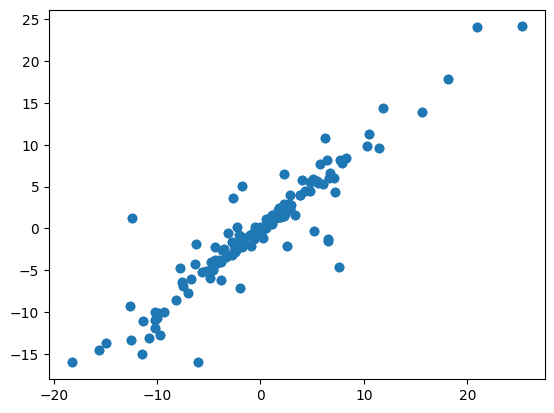

In [78]:
solve_beta_cg = solve_beta_cg_whitened
Fh = F_train.conj()
apply_fh = lambda x:  torch.einsum('bn,nm->bm', x.to(cdtype), Fh)
# Single RHS
rhs = fadj(m)
beta = solve_beta_cg(m, rhs, toeplitz, ws2, jitter, cg_tol=1e-6,max_iter=100_000,early_stopping=True)
# print cg residual magnitude

# print(beta)
# ---- Term 1: sum_m |β_m|^2 * Dprime_{m,p} ----
abs2 = (beta.conj() * beta).real                              # (M, P_rhs)
Dprime_ = Dprime.to(abs2.dtype)                               # (M, P_param) or (P_param, M)


term1 = Dprime_.T @ abs2               # (P_param, P_rhs)

print(term1)
plt.scatter(beta_vanilla.real,beta.real)



# Term 2

In [392]:
    J = 3

    # Generate probes

    probes = torch.empty((J, n), device=device, dtype=rdtype)
    # probes = probes.flatten()

    probes.bernoulli_(0.5).mul_(2).sub_(1)         # ±1
    # make isotropic normal probes
    # probes = torch.randn(J,n,device=device,dtype=cdtype)
    probes = probes.to(dtype=cdtype)


In [393]:
F_train.shape

torch.Size([700, 289])

cg iterations (whitened): 1330
CG time (whitened): 0.285s
CG residual |A_z z - rhs_z|: 0.005913382856079374


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


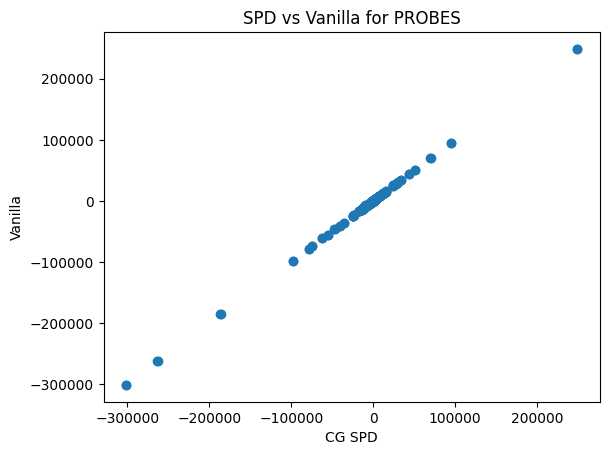

In [394]:
# CG (SPD form)
# beta_cg = solve_beta_cg_spd(probes, F_train, toeplitz, ws2, sigma2, cg_tol=1e-12)
rhs = fadj_batched(probes)
beta_cg = solve_beta_cg(probes, rhs, toeplitz, ws2, jitter, cg_tol = 1e-4,max_iter=10_000,early_stopping=True)


beta_van = FstarKinv@probes.T
plt.scatter(beta_cg,beta_van.T)
plt.xlabel("CG SPD")
plt.ylabel("Vanilla")
plt.title("SPD vs Vanilla for PROBES")
plt.show()


In [395]:
    J = 10

    # Generate probes

    probes = torch.empty((J, n), device=device, dtype=rdtype)
    # probes = probes.flatten()

    probes.bernoulli_(0.5).mul_(2).sub_(1)         # ±1
    # make isotropic normal probes
    # probes = torch.randn(J,n,device=device,dtype=cdtype)
    probes = probes.to(dtype=cdtype)
    rhs = fadj_batched(probes)
    beta_cg = solve_beta_cg(probes, rhs, toeplitz, ws2, jitter, cg_tol = 1e-6,max_iter=10_000,early_stopping=True)
    beta_van = (FstarKinv@probes.T).T
    p = (rhs * beta_cg.conj()).sum(dim=0)
    term3 = (p.real @ Dprime) / J

    Sz = Sigma_z_mm(z=probes,delta_buf=q.Delta,cg_tol=cg_tol,fadj_batched=fadj_batched,fwd_batched=fwd_batched,ws=ws,ws2=ws2,vanilla=True)
    t1 = time.time()
    sigma_z_time = t1 - t0
    
    t0 = time.time()
    rhs = fadj_batched(Sz)
    w = solve_beta_cg(Sz, rhs, toeplitz, ws2, jitter, cg_tol = 1e-10,max_iter=10_000,early_stopping=True)
    # inner_prod = (w.conj() * beta_cg)
    w_van = (FstarKinv@Sz.T).T

    term2 = torch.zeros(Dprime.shape[1],device=device,dtype=cdtype)
    term2_van = torch.zeros(Dprime.shape[1],device=device,dtype=cdtype)

    for dim in range(Dprime.shape[1]):
        term2[dim] = ((beta_cg.conj()@ torch.diag(Dprime[:,dim]).to(dtype=cdtype)) * w).real.sum(axis=1).mean()
        term2_van[dim] = ((beta_van.conj()@ torch.diag(Dprime[:,dim]).to(dtype=cdtype)) * w_van).real.sum(axis=1).mean()

print(f'term2: {term2}')
print(f'term2_van: {term2_van}')
print(f'term3: {term3}')


cg iterations (whitened): 4190
CG time (whitened): 2.045s
CG residual |A_z z - rhs_z|: 0.00012864442185122173
cg iterations (whitened): 10000
CG time (whitened): 4.914s
CG residual |A_z z - rhs_z|: 1.5806554853725035e-07
term2: tensor([-6742.9297+0.j,   138.7620+0.j])
term2_van: tensor([-6747.3322+0.j,   139.1029+0.j], grad_fn=<CopySlices>)
term3: tensor([-7560.1152,   185.6378])


In [396]:
print('Ground truth:')
print(f't1v1: {t1v1},t2v1: {t2v1},t3v1: {t3v1}')
print(f't1var: {t1var},t2var: {t2var},t3var: {t3var}')
print(f'gradient: {grad_ls}, {grad_var}')
print('######################## ')
print('Estimated:')
print(f'term1: {term1[0]},term2: {term2[0]},term3: {term3[0]}')
print(f'term1: {term1[1]},term2: {term2[1]},term3: {term3[1]}')
grad = 0.5*(term1+term2-term3 )
print(f'grad: {grad}')


Ground truth:
t1v1: -510.9862142107519,t2v1: -7653.671793595691,t3v1: -7973.217062209907
t1var: 30.158634798894063,t2var: 150.24495408832928,t3var: 186.53599252437562
gradient: -95.72047279826802, -3.0662018185761326
######################## 
Estimated:
term1: -511.00708369522135,term2: (-6742.929731223145+0j),term3: -7560.115245772498
term1: 30.159084414584786,term2: (138.76198790318176+0j),term3: 185.63777829601312
grad: tensor([153.0892+0.j,  -8.3584+0.j])


In [ ]:
# Calculate term2 and term3 10 times and create boxplots
import matplotlib.pyplot as plt
import numpy as np

# Reference values from vanilla gradient computation
t2v1_true = t2v1
t2var_true = t2var

# Store results for 10 runs
n_runs = 10
term2_results = []
term3_results = []

print("Running term2 and term3 calculation 10 times...")
for run in range(n_runs):
    print(f"Run {run+1}/{n_runs}")
    
    # Generate new random probes for each run
    J = 10
    probes = torch.empty((J, n), device=device, dtype=rdtype)
    probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
    probes = probes.to(dtype=cdtype)
    
    # Solve for beta_cg with new probes
    rhs = fadj_batched(probes)
    beta_cg = solve_beta_cg(probes, rhs, toeplitz, ws2, jitter, cg_tol=1e-4, max_iter=20_000, early_stopping=True)
    p = (rhs * beta_cg.conj()).sum(dim=0)
    term3 = (p.real @ Dprime) / J
    # Calculate Sz with new probes
    Sz = Sigma_z_mm(z=probes, delta_buf=q.Delta, cg_tol=cg_tol, fadj_batched=fadj_batched, 
                    fwd_batched=fwd_batched, ws=ws, ws2=ws2, vanilla=True)
    
    # Solve for w
    rhs = fadj_batched(Sz)
    w = solve_beta_cg(Sz, rhs, toeplitz, ws2, jitter, cg_tol=1e-8, max_iter=20_000, early_stopping=True)
    
    # Calculate term2
    term2 = torch.zeros(Dprime.shape[1], device=device, dtype=cdtype)
    for dim in range(Dprime.shape[1]):
        term2[dim] = ((beta_cg.conj() @ torch.diag(Dprime[:, dim]).to(dtype=cdtype)) * w).real.sum(axis=1).mean()
    term2_results.append(term2.detach().cpu().numpy())

    # Calculate term3 for this run

    term3_results.append(term3.detach().cpu().numpy())


Running term2 and term3 calculation 10 times...
Run 1/10
cg iterations (whitened): 1972
CG time (whitened): 0.935s
CG residual |A_z z - rhs_z|: 0.012730689498495665
cg iterations (whitened): 7185
CG time (whitened): 3.098s
CG residual |A_z z - rhs_z|: 3.5172376474007332e-06
Run 2/10
cg iterations (whitened): 2179
CG time (whitened): 0.952s
CG residual |A_z z - rhs_z|: 0.012752886338285238
cg iterations (whitened): 7584
CG time (whitened): 3.122s
CG residual |A_z z - rhs_z|: 3.0618763758593694e-06
Run 3/10
cg iterations (whitened): 2325
CG time (whitened): 1.003s
CG residual |A_z z - rhs_z|: 0.011050604084367175
cg iterations (whitened): 8599
CG time (whitened): 3.648s
CG residual |A_z z - rhs_z|: 2.5567336120507326e-06
Run 4/10
cg iterations (whitened): 2155
CG time (whitened): 0.896s
CG residual |A_z z - rhs_z|: 0.013552825398831797
cg iterations (whitened): 7259
CG time (whitened): 3.377s
CG residual |A_z z - rhs_z|: 3.316423041549136e-06
Run 5/10
cg iterations (whitened): 2249
CG ti

In [437]:
((rhs * beta_cg.conj()).sum(dim=0)).shape

torch.Size([289])

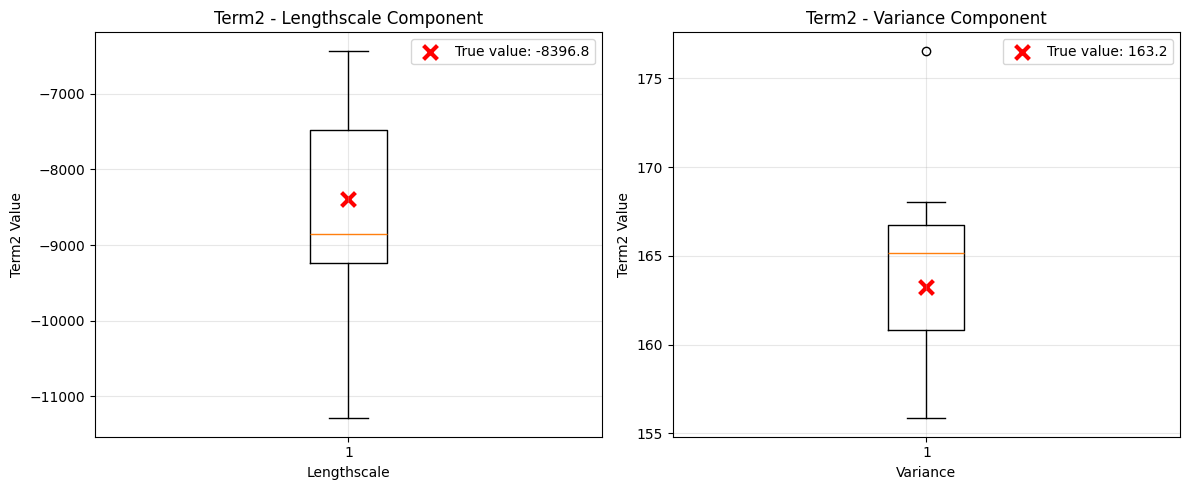

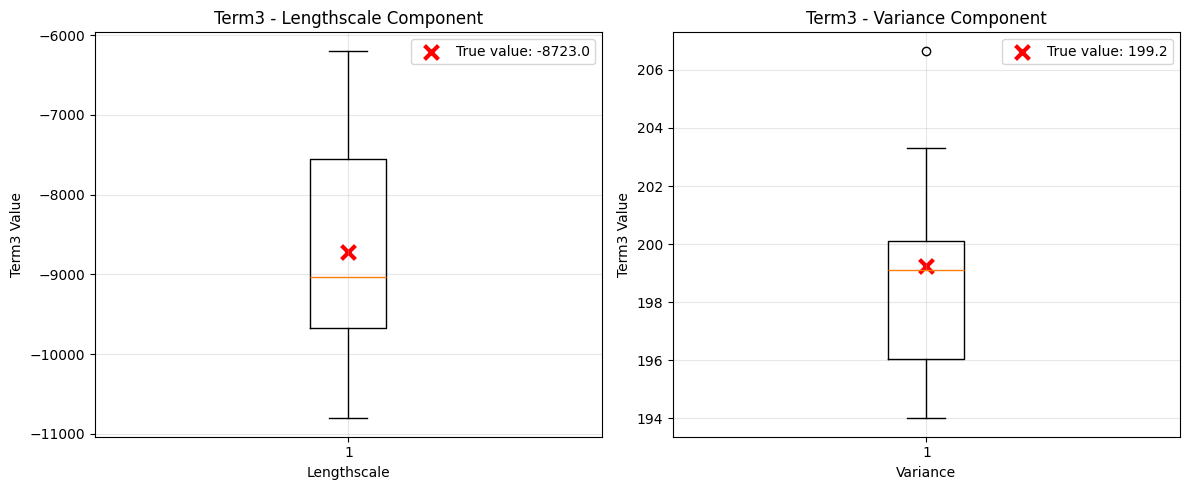


Term2 - Lengthscale component (dim 0):
  Mean: -8633.00
  Std:  1401.49
  True: -8396.75

Term2 - Variance component (dim 1):
  Mean: 164.40
  Std:  5.56
  True: 163.24

Term3 - Lengthscale component (dim 0):
  Mean: -8773.33
  Std:  1456.11
  True: -8722.97

Term3 - Variance component (dim 1):
  Mean: 198.84
  Std:  3.80
  True: 199.25


In [ ]:

# Convert to numpy array for easier handling, and ensure real values for plotting
term2_results = np.array(term2_results)
term3_results = np.array(term3_results)
if np.iscomplexobj(term2_results):
    term2_results = term2_results.real
if np.iscomplexobj(term3_results):
    term3_results = term3_results.real

# Ensure t2v1_true, t2var_true, t3v1, t3var are detached and converted to numpy scalars if they are torch tensors
def to_numpy_scalar(x):
    if hasattr(x, 'detach'):
        x = x.detach()
    if hasattr(x, 'cpu'):
        x = x.cpu()
    if hasattr(x, 'numpy'):
        x = x.numpy()
    # If still an array, get scalar
    if isinstance(x, np.ndarray):
        x = x.item()
    return float(np.real(x))  # ensure float and real

t2v1_true_np = to_numpy_scalar(t2v1_true)
t2var_true_np = to_numpy_scalar(t2var_true)
t3v1_true_np = to_numpy_scalar(t3v1)
t3var_true_np = to_numpy_scalar(t3var)

# Create boxplots for term2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Lengthscale boxplot (dimension 0)
ax1.boxplot(term2_results[:, 0])
ax1.scatter(1, t2v1_true_np, color='red', marker='x', s=100, linewidth=3, label=f'True value: {t2v1_true_np:.1f}')
ax1.set_title('Term2 - Lengthscale Component')
ax1.set_ylabel('Term2 Value')
ax1.set_xlabel('Lengthscale')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Variance boxplot (dimension 1)
ax2.boxplot(term2_results[:, 1])
ax2.scatter(1, t2var_true_np, color='red', marker='x', s=100, linewidth=3, label=f'True value: {t2var_true_np:.1f}')
ax2.set_title('Term2 - Variance Component')
ax2.set_ylabel('Term2 Value')
ax2.set_xlabel('Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create boxplots for term3, with ground truth x for t3v1 and t3var
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))

# Lengthscale boxplot (dimension 0)
ax3.boxplot(term3_results[:, 0])
ax3.scatter(1, t3v1_true_np, color='red', marker='x', s=100, linewidth=3, label=f'True value: {t3v1_true_np:.1f}')
ax3.set_title('Term3 - Lengthscale Component')
ax3.set_ylabel('Term3 Value')
ax3.set_xlabel('Lengthscale')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Variance boxplot (dimension 1)
ax4.boxplot(term3_results[:, 1])
ax4.scatter(1, t3var_true_np, color='red', marker='x', s=100, linewidth=3, label=f'True value: {t3var_true_np:.1f}')
ax4.set_title('Term3 - Variance Component')
ax4.set_ylabel('Term3 Value')
ax4.set_xlabel('Variance')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for term2
print(f"\nTerm2 - Lengthscale component (dim 0):")
print(f"  Mean: {np.mean(term2_results[:, 0]):.2f}")
print(f"  Std:  {np.std(term2_results[:, 0]):.2f}")
print(f"  True: {t2v1_true_np:.2f}")

print(f"\nTerm2 - Variance component (dim 1):")
print(f"  Mean: {np.mean(term2_results[:, 1]):.2f}")
print(f"  Std:  {np.std(term2_results[:, 1]):.2f}")
print(f"  True: {t2var_true_np:.2f}")

# Print summary statistics for term3
print(f"\nTerm3 - Lengthscale component (dim 0):")
print(f"  Mean: {np.mean(term3_results[:, 0]):.2f}")
print(f"  Std:  {np.std(term3_results[:, 0]):.2f}")
print(f"  True: {t3v1_true_np:.2f}")

print(f"\nTerm3 - Variance component (dim 1):")
print(f"  Mean: {np.mean(term3_results[:, 1]):.2f}")
print(f"  Std:  {np.std(term3_results[:, 1]):.2f}")
print(f"  True: {t3var_true_np:.2f}")

In [ ]:
beta_van.shape

torch.Size([10, 289])

cg iterations (whitened): 7717
CG time (whitened): 3.460s
CG residual |A_z z - rhs_z|: 3.184449840498455e-06


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


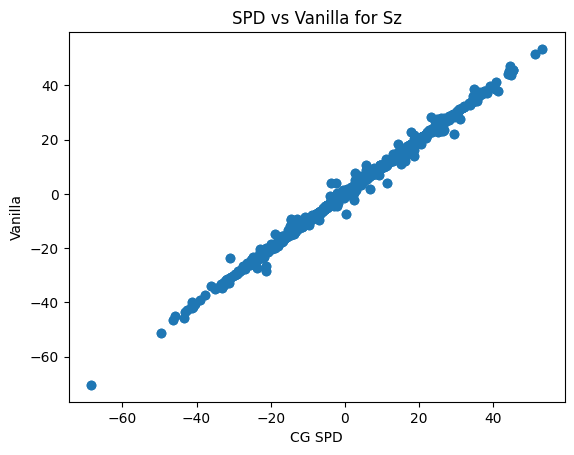

In [ ]:
# CG (SPD form)
# beta_cg = solve_beta_cg_spd(probes, F_train, toeplitz, ws2, sigma2, cg_tol=1e-12)
rhs = fadj_batched(Sz)
beta_cg = solve_beta_cg(Sz, rhs, toeplitz, ws2, jitter, cg_tol = 1e-8,max_iter=10_000,early_stopping=True)


beta_van = FstarKinv@Sz.T
plt.scatter(beta_cg.flatten(),beta_van.T.flatten().detach())
plt.xlabel("CG SPD")
plt.ylabel("Vanilla")
plt.title("SPD vs Vanilla for Sz")
plt.show()


Ground truth:
t1v1: -323.236593404585,t2v1: -8396.752199877936,t3v1: -8722.965879231459
t1var: 19.528514865216742,t2var: 163.24133842035928,t3var: 199.24803311243886
######################## 
Estimated:
term1: -323.4831872595872,term2: (-8804.461036194256+0j),term3: -9336.862208019158
term1: 19.536173769877536,term2: (166.91614566612807+0j),term3: 206.6609542915881


In [443]:
t2v1 - t3v1

tensor(319.5453, grad_fn=<SubBackward0>)

In [ ]:
0.5*(term1+term2-term3 )

tensor([104.4590+0.j, -10.1043+0.j])

In [ ]:
print(grad_ls,grad_var)

tensor(1.4885, grad_fn=<MulBackward0>) tensor(-8.2391, grad_fn=<MulBackward0>)


In [419]:
beta_cg.shape

torch.Size([10, 289])

In [471]:
term2

tensor([1.2338, 0.0655], grad_fn=<MulBackward0>)

In [472]:
t2v1 - t3v1

tensor(319.5453, grad_fn=<SubBackward0>)

In [29]:
# "Vanilla" (dense, direct inverses) implementation for the combined gradient:
#   dL/dθ_p = 0.5 * μ^T K^{-1} (∂K_p) K^{-1} μ  -  0.5 * tr( (I + ΩK)^{-1} Ω ∂K_p )
#
# Here:  K = F diag(D2) F*
#        ∂K_p = F diag(Dprime[:, p]) F*
#        Ω = diag(omega)  (omega is a length-n vector)
#
# Inputs you must provide:
#   F_train : (n, M)           # your F
#   D2      : (M,)             # diagonal entries of D^2
#   Dprime  : (M, P)           # columns are ∂(D^2)/∂θ_p  (P parameters)
#   omega   : (n,)             # diagonal of Ω
#   probes  : (B, n) or (n,)   # Hutch probes (rows); if 1D it's a single probe
#   mu      : (n,) or None     # posterior mean; if None, term1 is skipped
#
# This is intentionally naive: dense matrices, explicit inverses, and simple loops
# to make the math crystal-clear. Replace the inverses/loops with CG/SLQ later.
mu = m
omega = q.Delta
D2 = ws2


import torch

def gp_mstep_gradient_vanilla(F_train, D2, Dprime, omega, probes, mu=None):
    device = F_train.device
    # Choose complex dtype if any input is complex, else float64
    cdtype = (torch.complex128
              if (torch.is_complex(F_train) or torch.is_complex(D2) or torch.is_complex(Dprime))
              else torch.float64)

    F = F_train.to(cdtype)
    D2 = D2.to(cdtype)                 # (M,)
    if Dprime.ndim == 1:
        Dprime = Dprime[:, None]       # (M,1)
    Dprime = Dprime.to(cdtype)         # (M,P)
    omega = omega.to(cdtype)           # (n,)
    n, M = F.shape
    P = Dprime.shape[1]

    # Coerce probes to (B, n)
    probes = probes.to(cdtype)
    if probes.ndim == 1:
        probes = probes[None, :]
    B = probes.shape[0]

    # --- Build dense K, Ω, A ---
    # K = F diag(D2) F*
    K = F @ torch.diag(D2) @ F.conj().T                     # (n,n)
    Omega = torch.diag(omega)                               # (n,n)
    A = torch.eye(n, dtype=cdtype, device=device) + Omega @ K  # (n,n)

    # --- alpha = (A^{-1} probes^T)^T (rows are A^{-1} z_i) ---
    A_inv = torch.linalg.inv(A)                             # (n,n)
    alpha = (A_inv @ probes.T).T                            # (B,n)

    # --------- TRACE TERM  T_p = tr( A^{-1} Ω ∂K_p )  ----------
    # We'll compute bz_i,p = (Ω ∂K_p) z_i for all probes/params, then
    # Hutch:  T_p ≈ (1/B) Σ_i z_i^T A^{-1} (Ω ∂K_p) z_i = (1/B) Σ_i alpha_i^T bz_i,p
    #
    # Precompute F*Z  once: S = F* Z^T has shape (M,B)
    S = F.conj().T @ probes.T                               # (M,B)

    # For each parameter p:
    trace_est = torch.empty(P, dtype=torch.float64 if cdtype==torch.float64 else torch.float32, device=device)
    for p in range(P):
        # ∂K_p Z  = F diag(Dprime[:,p]) F* Z  = F ( diag(Dprime[:,p]) @ S )
        tmp = torch.diag(Dprime[:, p]) @ S                  # (M,B)
        dKZ = F @ tmp                                       # (n,B)
        BZ = (Omega @ dKZ).T                                # (B,n)

        # contraction: alpha_i^T (BZ)_i
        vals = (alpha.conj() * BZ).sum(dim=1).real          # (B,)
        trace_est[p] = vals.mean()

    # Combined trace contribution to gradient:  -0.5 * T_p
    grad_trace = -0.5 * trace_est                            # (P,)


    return {
        "K": K, "A": A, "A_inv": A_inv, "alpha": alpha,      # intermediates (for inspection)
        "trace_est": trace_est, "grad_trace": grad_trace,    # trace pieces
    }
grad_out = gp_mstep_gradient_vanilla(F_train, D2, Dprime, omega, probes, mu)

print(-grad_out['trace_est'])

tensor([312.5038, -38.3454], dtype=torch.float32, grad_fn=<NegBackward0>)


In [489]:
print(f'ls: {t2v1 - t3v1}')
print(f'var: {t2var - t3var}')

ls: 319.5452686142162
var: -36.291038436046335


In [52]:
import torch
probes = torch.empty((10, n), device=device, dtype=rdtype)
probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
probes = probes.to(dtype=cdtype)
def trace_term_hutch_vanilla_feature_space(F_train, D2, Dprime, omega, probes):
    """
    Estimate, for all params p, the Hutchinson average of
        z^T Ω F diag(D'_p) F^* (I + Ω K)^{-1} z,
    where K = F diag(D2) F^* and Ω = diag(omega).

    Shapes:
      F_train: (n, M)
      D2:      (M,)
      Dprime:  (M, P)           # columns are D'_p
      omega:   (n,)
      probes:  (B, n) or (n,)   # rows are probes (Rademacher/Gaussian)

    Returns:
      T_hat: (P,)  Hutchinson estimate (mean over probes)
      aux:   dict of intermediates for sanity-checking
    """
    cdtype = (torch.complex128 if (torch.is_complex(F_train)
                                   or torch.is_complex(D2)
                                   or torch.is_complex(Dprime))
              else torch.float64)

    F = F_train.to(cdtype)
    n, M = F.shape
    D2 = D2.to(cdtype).flatten()                       # (M,)
    D2_diag = torch.diag(D2)                           # (M,M)

    if Dprime.ndim == 1:
        Dprime = Dprime[:, None]
    Dprime = Dprime.to(cdtype)                         # (M,P)
    P = Dprime.shape[1]

    omega = omega.to(cdtype).flatten()                 # (n,)
    Omega = torch.diag(omega)                          # (n,n)

    probes = probes.to(cdtype)
    if probes.ndim == 1:
        probes = probes[None, :]                       # (1,n)
    Bsz = probes.shape[0]                              # number of probes

    # Weighted Gram in feature space: B = F^* Ω F  (M×M)
    Bmat = F.conj().mT @ (Omega @ F)

    # Feature-space system for β: (I + (F^* Ω F) diag(D2)) β = q, with q = F^* z
    A_M = torch.eye(M, dtype=cdtype, device=F.device) + (Bmat @ D2_diag)  
    apply_Am = lambda x: (A_M@x.T).T

  # precond using toeplitz
    toeplitz_sys = lambda x: (x + q.Delta.mean()*toeplitz(D2*x))


    # "Vanilla" dense solve for all probes at once:

    # Q = (F.conj().mT @ probes.mT)                      # (M,B)
    # cg0 = ConjugateGradients(toeplitz_sys, Q.T, tol=1e-6, x0=torch.zeros_like(Q.T), max_iter=10_000, early_stopping=True,)
    # y0 = cg0.solve().T
    # cg = ConjugateGradients(apply_Am, Q.T, tol=1e-6, x0=y0.T, max_iter=10_000, early_stopping=True)
    # Beta = cg.solve().T
    # print(f'warm start toeplitz iters: {cg.iters_completed}')
    # cg = ConjugateGradients(apply_Am, Q.T, tol=1e-6, x0=torch.zeros_like(Q.T), max_iter=10_000, early_stopping=True)
    # Beta = cg.solve().T
    # print(f'no warm start iters: {cg.iters_completed}')



    # shapes: F (n,M), D2 (M,), omega (n,), probes (B,n)
    cdtype = F.dtype
    M = F.shape[1]

    Omega = torch.diag(omega.to(cdtype))
    Bmat  = F.conj().mT @ (Omega @ F)                                      # (M,M)
    D2_diag = torch.diag(D2.to(cdtype))
    A_M  = torch.eye(M, dtype=cdtype, device=F.device) + (Bmat @ D2_diag)   # (M,M)
    apply_Am = lambda X: (A_M @ X.T).T                                      # (B,M) -> (B,M)

    Q_block = (F.conj().mT @ probes.to(cdtype).mT).T                        # (B,M)

    wbar = omega.to(cdtype).real.mean()

    # Toeplitz surrogate: Ã ≈ I + w̄ * T * diag(D2)
    def toeplitz_sys(X):                                                    # (B,M)->(B,M)
        Y = X                                                            # (M,B)
        Y = Y + wbar * toeplitz(D2 * Y)                 # T @ (D2 * Y)
        return Y

    # --- warm start y0 = Ã^{-1} Q ---
    cg0  = ConjugateGradients(toeplitz_sys, Q_block, tol=1e-6,
                              x0=torch.zeros_like(Q_block), max_iter=200, early_stopping=True)
    y0   = cg0.solve()                                                      # (B,M)

    # --- one residual polish: y0 += Ã^{-1} (Q - A_M y0) ---
    R    = Q_block - apply_Am(y0)                                           # (B,M)
    cg1  = ConjugateGradients(toeplitz_sys, R, tol=1e-6,
                              x0=torch.zeros_like(R), max_iter=100, early_stopping=True)
    y0   = y0 + cg1.solve()                                                 # (B,M)

    # --- main solve with your CG, warm-started ---
    cg   = ConjugateGradients(apply_Am, Q_block, tol=1e-4,
                              x0=y0, max_iter=10_000, early_stopping=True)
    Beta = cg.solve().T                                                     # (M,B)
    print("third version iters:", cg.iters_completed)







    # Beta_van = torch.linalg.solve(A_M, Q)                  # (M,B), columns β_i

    # r_i = F^* (Ω z_i), stacked as (M,B)
    R = F.conj().mT @ (Omega @ probes.mT)              # (M,B)

    # For each probe i and param p: s_{i,p} = Re( conj(R[:,i]) · (D'_p ⊙ Beta[:,i]) )
    # Pack this as a matrix multiply: with X = (conj(R) ⊙ Beta)  (M,B),
    # vals = (X^T @ Dprime) -> (B,P), then mean over probes.
    X = (R.conj() * Beta)                              # (M,B)
    vals = (X.mT @ Dprime).real                        # (B,P)
    T_hat = vals.mean(dim=0)                           # (P,)

    return T_hat, {"B": Bmat, "A_M": A_M, "Q": Q_block, "Beta": Beta, "R": R, "vals": vals}
out = trace_term_hutch_vanilla_feature_space(F_train, D2, Dprime, omega, probes)
out[1]['vals'].mean(dim=0)

third version iters: 4


tensor([-312.6442,   38.1626], grad_fn=<MeanBackward1>)

In [635]:
0.5*term1 - 0.5*(out[1]['vals'].mean(dim=0))

tensor([-79.2991,  -2.8851], grad_fn=<SubBackward0>)

In [637]:
print(f'grad: {grad_ls}, {grad_var}')

grad: -95.72047279826802, -3.0662018185761326
